# How Fast Must Sound Move for a Semitone Shift?

A **semitone** is the smallest standard step in Western music (e.g. C → C♯). In frequency terms that is the fixed ratio

$$
r = 2^{1/12} \approx 1.05946
$$

so the observed pitch goes up or down by one semitone when the observed frequency is multiplied by \(r\) or \(1/r\).

For a **stationary listener** and a **moving source**, the classical Doppler formula is

$$
f' = f \cdot \frac{v}{v \mp v_s}
$$

- \(v\): speed of sound in air
- \(v_s\): source speed along the line of sight
- minus (−) when the source **approaches** (pitch rises)
- plus (+) when the source **recedes** (pitch falls)

This notebook solves for the source speed \(v_s\) that produces exactly one semitone of shift, then plots how that speed depends on air temperature and how pitch changes with speed.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Semitone frequency ratio
R_SEMITONE = 2 ** (1 / 12)
print(f"One semitone ratio r = 2^(1/12) = {R_SEMITONE:.6f}")
print(f"Cents in one semitone: {1200 * np.log2(R_SEMITONE):.1f}")

One semitone ratio r = 2^(1/12) = 1.059463
Cents in one semitone: 100.0


## Speed of sound vs temperature

In dry air near sea level,

$$
v(T) \approx 331.3 \sqrt{1 + \frac{T_{^\circ\mathrm{C}}}{273.15}} \;\mathrm{m/s}
$$

At 20 °C that is about **343 m/s**.

In [2]:
def speed_of_sound(temp_c: float | np.ndarray) -> float | np.ndarray:
    """Speed of sound in dry air [m/s] from temperature in Celsius."""
    return 331.3 * np.sqrt(1.0 + np.asarray(temp_c, dtype=float) / 273.15)


temps_c = np.linspace(-20, 40, 13)
for t in temps_c[::3]:
    print(f"T = {t:5.1f} C  ->  v = {speed_of_sound(t):6.2f} m/s")

T = -20.0 C  ->  v = 318.94 m/s
T =  -5.0 C  ->  v = 328.25 m/s
T =  10.0 C  ->  v = 337.31 m/s
T =  25.0 C  ->  v = 346.13 m/s
T =  40.0 C  ->  v = 354.73 m/s


## Source speed for ±1 semitone

Solve the Doppler formula for \(v_s\):

**Approaching** (heard higher by one semitone):

$$
\frac{v}{v - v_s} = r \quad\Rightarrow\quad v_s^{\mathrm{approach}} = v\left(1 - \frac{1}{r}\right)
$$

**Receding** (heard lower by one semitone):

$$
\frac{v}{v + v_s} = \frac{1}{r} \quad\Rightarrow\quad v_s^{\mathrm{recede}} = v\,(r - 1)
$$

These are **not equal**: Doppler shift is asymmetric in approach vs recession.

In [3]:
def vs_approach_semitone(v: float | np.ndarray, r: float = R_SEMITONE) -> float | np.ndarray:
    """Source speed [m/s] for +1 semitone when approaching."""
    return np.asarray(v) * (1.0 - 1.0 / r)


def vs_recede_semitone(v: float | np.ndarray, r: float = R_SEMITONE) -> float | np.ndarray:
    """Source speed [m/s] for -1 semitone when receding."""
    return np.asarray(v) * (r - 1.0)


def mps_to_kmh(mps: float | np.ndarray) -> float | np.ndarray:
    return np.asarray(mps) * 3.6


def mps_to_mph(mps: float | np.ndarray) -> float | np.ndarray:
    return np.asarray(mps) * 2.2369362920544


# Reference: 20 C
v20 = float(speed_of_sound(20.0))
vs_app = float(vs_approach_semitone(v20))
vs_rec = float(vs_recede_semitone(v20))

print(f"Speed of sound at 20 C: {v20:.2f} m/s")
print()
print("For a one-semitone pitch change:")
print(f"  Approaching: {vs_app:.2f} m/s  = {mps_to_kmh(vs_app):.1f} km/h  = {mps_to_mph(vs_app):.1f} mph")
print(f"  Receding:    {vs_rec:.2f} m/s  = {mps_to_kmh(vs_rec):.1f} km/h  = {mps_to_mph(vs_rec):.1f} mph")
print(f"  Difference:  {vs_rec - vs_app:.2f} m/s")

Speed of sound at 20 C: 343.21 m/s

For a one-semitone pitch change:
  Approaching: 19.26 m/s  = 69.3 km/h  = 43.1 mph
  Receding:    20.41 m/s  = 73.5 km/h  = 45.7 mph
  Difference:  1.15 m/s


## Plot 1 — Required source speed vs air temperature

As air warms, sound travels faster, so the source must move a bit faster to produce the same fractional frequency shift.

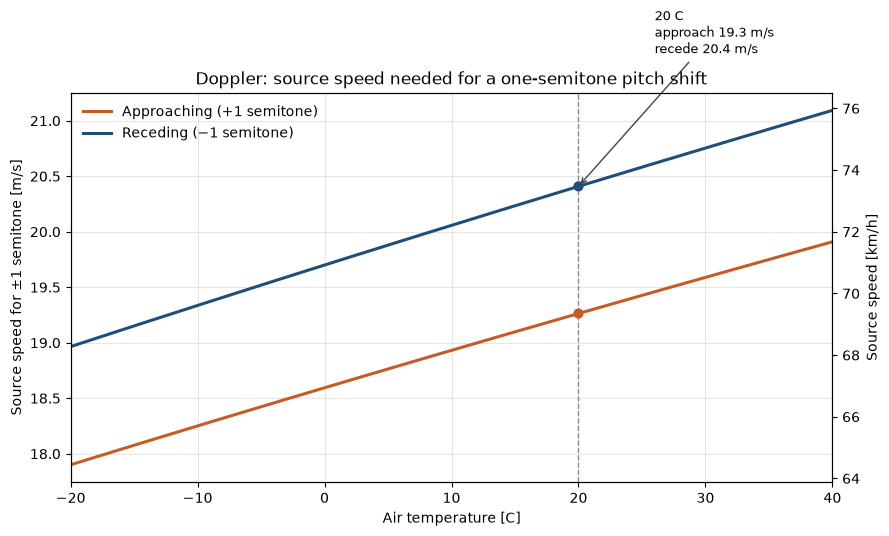

In [4]:
temps = np.linspace(-20, 40, 200)
v = speed_of_sound(temps)
vs_app_curve = vs_approach_semitone(v)
vs_rec_curve = vs_recede_semitone(v)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(temps, vs_app_curve, color="#c45c26", lw=2.2, label=r"Approaching (+1 semitone)")
ax.plot(temps, vs_rec_curve, color="#1f4e79", lw=2.2, label=r"Receding (−1 semitone)")

# Mark 20 C
ax.axvline(20, color="#666666", ls="--", lw=1, alpha=0.7)
ax.scatter([20, 20], [vs_app, vs_rec], color=["#c45c26", "#1f4e79"], zorder=5, s=40)
ax.annotate(
    f"20 C\napproach {vs_app:.1f} m/s\nrecede {vs_rec:.1f} m/s",
    xy=(20, vs_rec),
    xytext=(26, vs_rec + 1.2),
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color="#444444"),
)

ax.set_xlabel("Air temperature [C]")
ax.set_ylabel("Source speed for ±1 semitone [m/s]")
ax.set_title("Doppler: source speed needed for a one-semitone pitch shift")
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)
ax.set_xlim(temps.min(), temps.max())

# Secondary axis in km/h
ax2 = ax.twinx()
ymin, ymax = ax.get_ylim()
ax2.set_ylim(ymin * 3.6, ymax * 3.6)
ax2.set_ylabel("Source speed [km/h]")

fig.tight_layout()
plt.show()

## Plot 2 — Observed pitch shift vs source speed

How many semitones (and cents) you hear as a function of source speed at 20 °C.
1 semitone = 100 cents.

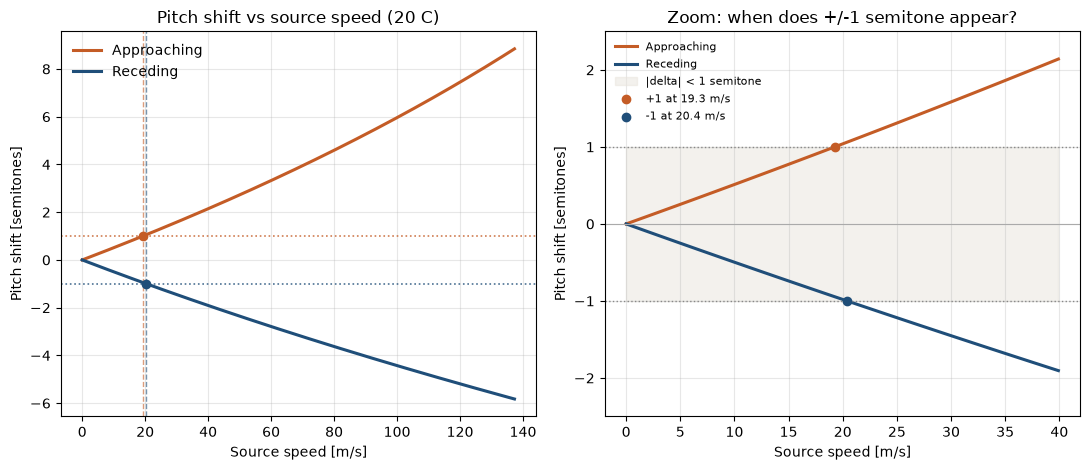

In [5]:
v_ref = speed_of_sound(20.0)
# Source speeds from 0 up to ~0.4 Mach (well below sound speed)
vs = np.linspace(0, 0.4 * v_ref, 400)

# Observed frequency ratios
ratio_approach = v_ref / (v_ref - vs)
ratio_recede = v_ref / (v_ref + vs)

semitones_approach = 12 * np.log2(ratio_approach)
semitones_recede = 12 * np.log2(ratio_recede)  # negative

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=False)

# Left: semitones vs speed
ax = axes[0]
ax.plot(vs, semitones_approach, color="#c45c26", lw=2.2, label="Approaching")
ax.plot(vs, semitones_recede, color="#1f4e79", lw=2.2, label="Receding")
ax.axhline(1, color="#c45c26", ls=":", lw=1.2, alpha=0.8)
ax.axhline(-1, color="#1f4e79", ls=":", lw=1.2, alpha=0.8)
ax.axvline(vs_app, color="#c45c26", ls="--", lw=1, alpha=0.6)
ax.axvline(vs_rec, color="#1f4e79", ls="--", lw=1, alpha=0.6)
ax.scatter([vs_app], [1], color="#c45c26", zorder=5)
ax.scatter([vs_rec], [-1], color="#1f4e79", zorder=5)
ax.set_xlabel("Source speed [m/s]")
ax.set_ylabel("Pitch shift [semitones]")
ax.set_title("Pitch shift vs source speed (20 C)")
ax.legend(frameon=False, loc="upper left")
ax.grid(True, alpha=0.3)

# Right: zoom near one semitone
ax = axes[1]
mask = vs <= 40
ax.plot(vs[mask], semitones_approach[mask], color="#c45c26", lw=2.2, label="Approaching")
ax.plot(vs[mask], semitones_recede[mask], color="#1f4e79", lw=2.2, label="Receding")
ax.axhline(1, color="#888888", ls=":", lw=1)
ax.axhline(-1, color="#888888", ls=":", lw=1)
ax.axhline(0, color="#aaaaaa", lw=0.8)
ax.fill_between(vs[mask], -1, 1, color="#e8e4dc", alpha=0.5, label="|delta| < 1 semitone")
ax.scatter([vs_app], [1], color="#c45c26", zorder=5, label=f"+1 at {vs_app:.1f} m/s")
ax.scatter([vs_rec], [-1], color="#1f4e79", zorder=5, label=f"-1 at {vs_rec:.1f} m/s")
ax.set_xlabel("Source speed [m/s]")
ax.set_ylabel("Pitch shift [semitones]")
ax.set_title("Zoom: when does +/-1 semitone appear?")
ax.legend(frameon=False, fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(-2.5, 2.5)

fig.tight_layout()
plt.show()

## Plot 3 — Everyday speed comparisons

Put the ~20 m/s threshold next to familiar speeds.

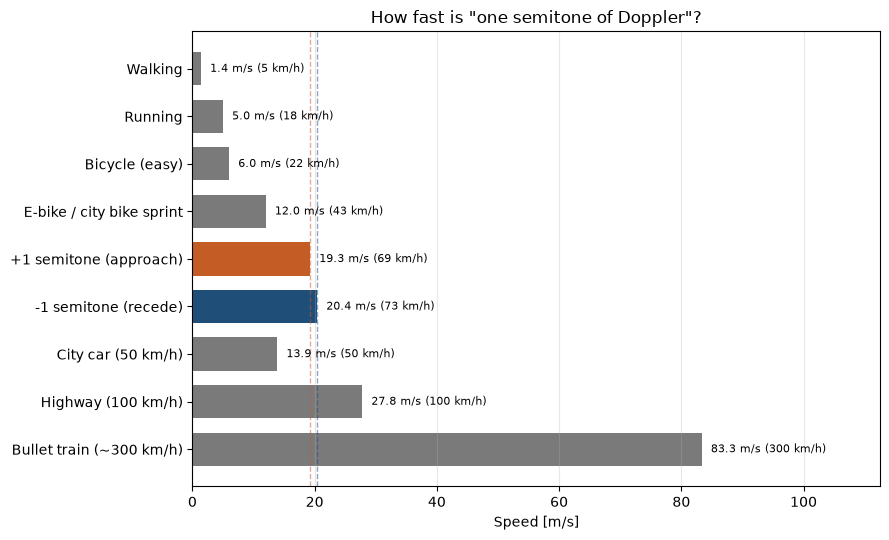

In [6]:
comparisons = [
    ("Walking", 1.4),
    ("Running", 5.0),
    ("Bicycle (easy)", 6.0),
    ("E-bike / city bike sprint", 12.0),
    ("+1 semitone (approach)", vs_app),
    ("-1 semitone (recede)", vs_rec),
    ("City car (50 km/h)", 50 / 3.6),
    ("Highway (100 km/h)", 100 / 3.6),
    ("Bullet train (~300 km/h)", 300 / 3.6),
]

labels = [c[0] for c in comparisons]
speeds = np.array([c[1] for c in comparisons])
colors = []
for name, _ in comparisons:
    if "semitone" in name and "approach" in name:
        colors.append("#c45c26")
    elif "semitone" in name:
        colors.append("#1f4e79")
    else:
        colors.append("#7a7a7a")

fig, ax = plt.subplots(figsize=(9, 5.5))
y = np.arange(len(labels))
ax.barh(y, speeds, color=colors, height=0.7)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel("Speed [m/s]")
ax.set_title('How fast is "one semitone of Doppler"?')
ax.axvline(vs_app, color="#c45c26", ls="--", lw=1, alpha=0.5)
ax.axvline(vs_rec, color="#1f4e79", ls="--", lw=1, alpha=0.5)

for yi, s in zip(y, speeds):
    ax.text(s + 1.5, yi, f"{s:.1f} m/s ({mps_to_kmh(s):.0f} km/h)", va="center", fontsize=8)

ax.set_xlim(0, max(speeds) * 1.35)
ax.invert_yaxis()
ax.grid(True, axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

## Plot 4 — Semitones vs Mach number

Mach number \( M = v_s / v \) makes the result temperature-independent:

$$
\Delta\mathrm{semitones}_{\mathrm{approach}} = 12\log_2\!\frac{1}{1-M},
\qquad
\Delta\mathrm{semitones}_{\mathrm{recede}} = 12\log_2\!\frac{1}{1+M}
$$

So the one-semitone thresholds are fixed Mach fractions:

$$
M_{\mathrm{approach}} = 1 - \tfrac{1}{r} \approx 0.0561,
\qquad
M_{\mathrm{recede}} = r - 1 \approx 0.0595
$$

Mach for +1 semitone (approach): 0.05613  (5.61% of sound speed)
Mach for -1 semitone (recede):   0.05946  (5.95% of sound speed)


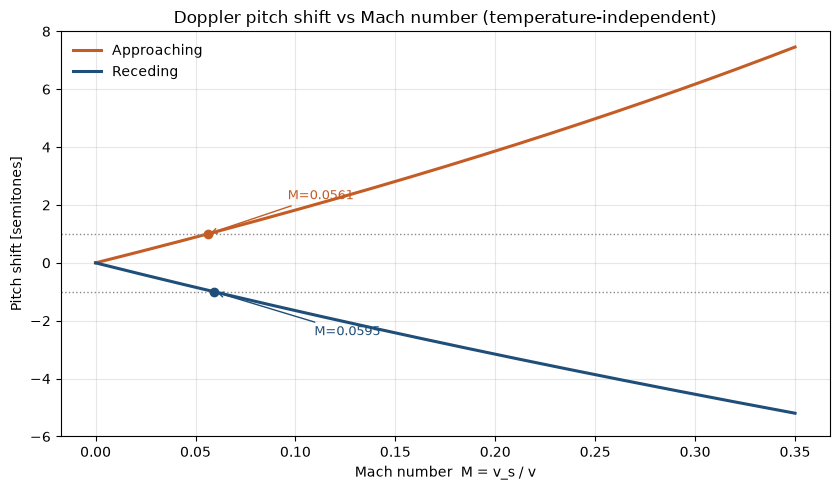

In [7]:
M_app = 1.0 - 1.0 / R_SEMITONE
M_rec = R_SEMITONE - 1.0
print(f"Mach for +1 semitone (approach): {M_app:.5f}  ({100*M_app:.2f}% of sound speed)")
print(f"Mach for -1 semitone (recede):   {M_rec:.5f}  ({100*M_rec:.2f}% of sound speed)")

mach = np.linspace(0, 0.35, 400)
st_app = 12 * np.log2(1.0 / (1.0 - mach))
st_rec = 12 * np.log2(1.0 / (1.0 + mach))

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(mach, st_app, color="#c45c26", lw=2.2, label="Approaching")
ax.plot(mach, st_rec, color="#1f4e79", lw=2.2, label="Receding")
ax.axhline(1, color="#888888", ls=":", lw=1)
ax.axhline(-1, color="#888888", ls=":", lw=1)
ax.scatter([M_app], [1], color="#c45c26", zorder=5)
ax.scatter([M_rec], [-1], color="#1f4e79", zorder=5)
ax.annotate(
    f"M={M_app:.4f}",
    xy=(M_app, 1),
    xytext=(M_app + 0.04, 2.2),
    arrowprops=dict(arrowstyle="->", color="#c45c26"),
    color="#c45c26",
    fontsize=9,
)
ax.annotate(
    f"M={M_rec:.4f}",
    xy=(M_rec, -1),
    xytext=(M_rec + 0.05, -2.5),
    arrowprops=dict(arrowstyle="->", color="#1f4e79"),
    color="#1f4e79",
    fontsize=9,
)
ax.set_xlabel("Mach number  M = v_s / v")
ax.set_ylabel("Pitch shift [semitones]")
ax.set_title("Doppler pitch shift vs Mach number (temperature-independent)")
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)
ax.set_ylim(-6, 8)
fig.tight_layout()
plt.show()

## Takeaways

1. **~20 m/s (~70 km/h)** is the ballpark source speed for a **one-semitone** Doppler shift in everyday air.
2. Approach and recession differ slightly: you need a bit **less** speed approaching (\(\approx 19.3\,\mathrm{m/s}\)) than receding (\(\approx 20.4\,\mathrm{m/s}\)) at 20 °C.
3. In Mach terms: about **5.6%** of the speed of sound approaching, **5.9%** receding.
4. A walking or jogging person does **not** produce a musical-semitone Doppler shift; a car at city speeds **does**.
5. Caveats: this is the ideal line-of-sight, stationary-observer formula. Real scenes have angle dependence (\(v_s \cos\theta\)), wind, humidity, and (for moving listeners) a different Doppler form.

### Just-noticeable difference (JND)

Psychoacoustics puts pitch JND near **~5 cents** (~1/20 semitone) for pure tones under good conditions, and larger for complex/noisy sounds. So the *perceptible* Doppler threshold can be well below one semitone — but one semitone is the musically meaningful “clearly different note” scale used here.

In [8]:
# Optional: speed for a just-noticeable ~5-cent shift at 20 C
cents_jnd = 5.0
r_jnd = 2 ** (cents_jnd / 1200)
vs_jnd_app = float(vs_approach_semitone(v20, r=r_jnd))
vs_jnd_rec = float(vs_recede_semitone(v20, r=r_jnd))
print(f"For a ~{cents_jnd:.0f}-cent JND at 20 C:")
print(f"  Approaching: {vs_jnd_app:.2f} m/s ({mps_to_kmh(vs_jnd_app):.1f} km/h)")
print(f"  Receding:    {vs_jnd_rec:.2f} m/s ({mps_to_kmh(vs_jnd_rec):.1f} km/h)")

For a ~5-cent JND at 20 C:
  Approaching: 0.99 m/s (3.6 km/h)
  Receding:    0.99 m/s (3.6 km/h)
